## Библиотеки

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt 

import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_white, het_breuschpagan
import scipy.stats as stats
import statsmodels.stats.diagnostic as sm_diagnostic
import statsmodels.stats.stattools as sm_tools

from statsmodels.stats.outliers_influence import variance_inflation_factor as vif
from sklearn.decomposition import PCA
from scipy.stats import kstest, zscore
from statsmodels.stats.diagnostic import het_goldfeldquandt
from statsmodels.stats.stattools import durbin_watson
from scipy.stats import shapiro
from statsmodels.stats.diagnostic import linear_reset
from scipy.stats import f
from scipy.stats import jarque_bera

from sklearn.linear_model import LinearRegression

## Создание единого датасета

### Мапы и нормализация зп

In [5]:
df20161 = pd.read_stata('r25i_os_73.dta', convert_categoricals = False)
df20211 = pd.read_stata('r30i_os_73.dta', convert_categoricals = False)

In [415]:
df2016 = df20161[["uj13_2", "uh5", "u_age", "u_diplom", "u_educ", "u_marst", "uj4_1", "region", 
                 "status", "popul", "uj77", "ui1", "ui3", "ui4", "uj1", "uj6", "uj6_1a", "uj322", 
                 "uj72_173", "uj72_172", "um1", "um2", "um3", "um71", "um80", "uj71", "uj72_1a",
                 'uj1_1_1', 'uj1_1_3', 'uj6_0', 'uj6_2', 'uj11', 'uj13', 'uj7_1', 'uj21_3',
                 'uj26', 'uj29_2_1', 'uj32']]

In [417]:
df2021 = df20211[["zj13_2", "zh5", "z_age", "z_diplom", "z_educ", "z_marst", "zj4_1", "region",
                 "status", "popul", "zj77", "zi1", "zi3", "zi4", "zj1", "zj6", "zj6_1a", "zj322",
                 "zj72_173", "zj72_172", "zm1", "zm2", "zm3", "zm71", "zm80", "zj71", "zj72_1a",
                 'zj1_1_1', 'zj1_1_3', 'zj6_0', 'zj6_2', 'zj11', 'zj7_1', 'zj13','zj21_3', 
                 'zj26', 'zj29_2_1', 'zj32']]

In [419]:
map2016 = {
    'uj13_2': 'wage16',
    'uh5': 'sex16',
    'u_age': 'age16',
    'u_diplom': 'diplom16',
    'u_educ': 'educ16',
    'u_marst': 'marital_stat16',
    'uj77': 'employed16',
    'uj4_1': 'industry16',
    'region': 'region16',
    'status': 'status16',
    'popul': 'popul16',
    'ui1': 'pereezd16',
    'ui3': 'city_type16',
    'ui4': 'nationality16',
    'uj1': 'main_activity16',
    'uj6': 'subordinates16',
    'uj6_1a': 'work_day_h16',
    'uj322': 'married16',
    'uj72_173': 'children16',
    'uj72_172': 'number_children16',
    'um1': 'weight16',
    'um2': 'height16',
    'um3': 'health16',
    'um71': 'smoking16',
    'um80': 'alco16',
    'uj71': 'ucheba_vne_school16',
    'uj72_1a': 'prof_kursi16',
    "uj1_1_1": "sat16",
    "uj1_1_3": "wage_sat16",
    "uj6_0": "num_sobordinates16",
    "uj6_2": "work_week16",
    "uj11": "type_comp16",
    "uj7_1": "num_work_daysm16",
    "uj13": "num_of_work16",
    "uj21_3": "danger_comp16",
    "uj26": "bus_owner16",
    "uj29_2_1": "promotion_w16",
    "uj32": "sec_job16"
}

map2021 = {
    'zj13_2': 'wage21',
    'zh5': 'sex21',
    'z_age': 'age21',
    'z_diplom': 'diplom21',
    'z_educ': 'educ21',
    'z_marst': 'marital_stat21',
    'zj77': 'employed21',
    'zj4_1': 'industry21',
    'region': 'region21',
    'status': 'status21',
    'popul': 'popul21',
    'zi1': 'pereezd21',
    'zi3': 'city_type21',
    'zi4': 'nationality21',
    'zj1': 'main_activity21',
    'zj6': 'subordinates21',
    'zj6_1a': 'work_day_h21',
    'zj322': 'married21',
    'zj72_173': 'children21',
    'zj72_172': 'number_children21',
    'zm1': 'weight21',
    'zm2': 'height21',
    'zm3': 'health21',
    'zm71': 'smoking21',
    'zm80': 'alco21',
    'zj71': 'ucheba_vne_school21',
    'zj72_1a': 'prof_kursi21',
    "zj1_1_1": "sat21",
    "zj1_1_3": "wage_sat21",
    "zj6_0": "num_sobordinates21",
    "zj6_2": "work_week21",
    "zj11": "type_comp21",
    "zj7_1": "num_work_daysm21",
    "zj13": "num_of_work21",
    "zj21_3": "danger_comp21",
    "zj26": "bus_owner21",
    "zj29_2_1": "promotion_w21",
    "zj32": "sec_job21"
}

In [421]:
df2016 = df2016.rename(mapper = map2016, axis = 1)
df2021 = df2021.rename(mapper = map2021, axis = 1)

In [423]:
df2016 = df2016.dropna(subset=['wage16'])
df2021 = df2021.dropna(subset=['wage21'])

#коррекция на инфляцию
df2021['wage21'] = df2021['wage21'] / 1.32

#сатисфекшн
replace_map = {1: 0, 2: 0, 3: 1, 4: 1, 5: 1}
df2016['sat16'] = df2016['sat16'].replace(replace_map)
df2021['sat21'] = df2021['sat21'].replace(replace_map)
df2016['wage_sat16'] = df2016['wage_sat16'].replace(replace_map)
df2021['wage_sat21'] = df2021['wage_sat21'].replace(replace_map)

#пол и наличие детей
sc_map = {1: 0, 2: 1}
df2016['sex16'] = df2016['sex16'].replace(sc_map)
df2021['sex21'] = df2021['sex21'].replace(sc_map)
df2016['children16'] = df2016['children16'].replace(sc_map)
df2021['children21'] = df2021['children21'].replace(sc_map)

#диплом
diplom_map = {1: 0, 2: 0, 3: 0, 4: 0, 5: 0, 6: 1}
df2016['diplom16'] = df2016['diplom16'].replace(diplom_map) #0 - обычное, 1 - высшее
df2021['diplom21'] = df2021['diplom21'].replace(diplom_map)

#статус семьи
marital_stat_map = {1: 0, 2: 1, 3: 1, 4: 0, 5: 0, 6: 0, 7: 1}
df2016['marital_stat16'] = df2016['marital_stat16'].replace(marital_stat_map) #1 - живут вместе или в браке, #0 все остальное
df2021['marital_stat21'] = df2021['marital_stat21'].replace(marital_stat_map)

#активность
main_activity_map = {1: 0, 2: 1, 3: 1, 4: 2, 5: 2}
df2016['main_activity16'] = df2016['main_activity16'].replace(main_activity_map) #0 - работает, #1 - опл. отпуск #2 - лодырь
df2021['main_activity21'] = df2021['main_activity21'].replace(main_activity_map)

#здоровье
health_map = {1: 0, 2: 0, 3: 1, 4: 1, 5: 1}
df2016['health16'] = df2016['health16'].replace(health_map) #0 - отличное #1 - среднее и плохое
df2021['health21'] = df2021['health21'].replace(health_map)

#национальность
nationality_mapping = {
    # РУССКИЕ (1)
    1: 1, 2: 1, 4: 1, 23: 1, 50: 1, 74: 1,
    # БЛИЖНЕЕ ЗАРУБЕЖЬЕ (2)
    3: 2, 7: 2, 13: 2, 96: 2, 24: 2, 41: 2, 57: 2, 167: 2, 169: 2, 90: 2, 86: 2, 110: 2, 107: 2,
    # КАВКАЗЦЫ (3)
    8: 3, 36: 3, 37: 3, 56: 3, 63: 3, 18: 3, 32: 3, 33: 3, 34: 3, 22: 3, 27: 3, 28: 3, 29: 3, 30: 3, 76: 3, 146: 3, 81: 3, 82: 3, 98: 3, 166: 3,
    # СРЕДНЯЯ АЗИЯ (4)
    43: 4, 38: 4, 93: 4, 19: 4, 58: 4,
    # НАРОДЫ РФ (5)
    14: 5, 6: 5, 80: 5, 9: 5, 11: 5, 12: 5, 85: 5, 21: 5, 16: 5, 65: 5, 17: 5, 39: 5, 158: 5, 60: 5, 52: 5, 100: 5, 35: 5, 88: 5, 170: 5, 112: 5,
    # ЕВРОПЕЙЦЫ (6)
    10: 6, 15: 6, 5: 6, 31: 6, 25: 6, 49: 6, 67: 6, 91: 6, 111: 6,
    # ДРУГОЕ (7)
    20: 7, 40: 7, 51: 7, 53: 7, 59: 7, 64: 7, 66: 7, 69: 7, 72: 7, 77: 7, 94: 7, 95: 7, 123: 7, 126: 7, 127: 7
}

df2016['nationality16'] = df2016['nationality16'].replace(nationality_mapping)
df2021['nationality21'] = df2021['nationality21'].replace(nationality_mapping)

#индустрии
industry_mapping = {
    9: 0, 10: 0, 11: 0, 12: 0, 13: 0, 14: 0, 17: 0, 20: 0, 23: 0, 24: 0, 28: 0, 32: 0, 25: 0, 26: 0, 29: 0,  # Зеленые (0)
    1: 1, 2: 1, 3: 1, 5: 1, 6: 1, 7: 1, 8: 1, 16: 1,                              # Желтые (1)
    15: 2, 18: 2, 21: 2, 27: 2, 30: 2, 31: 2, 4: 2                                # Синие (2)
}

df2016['industry16'] = df2016['industry16'].replace(industry_mapping)
df2021['industry21'] = df2021['industry21'].replace(industry_mapping)

subordinates_mapping = {1:1, 2:0} # 1 - есть подчиненные, 0 - нет
df2016['subordinates16'] = df2016['subordinates16'].replace(subordinates_mapping)
df2021['subordinates21'] = df2021['subordinates21'].replace(subordinates_mapping)

business_mapping = {1:1, 2:0} # 1 теперь - владение, 0 теперь - невладение
df2016['bus_owner16'] = df2016['bus_owner16'].replace(business_mapping)
df2021['bus_owner21'] = df2021['bus_owner21'].replace(business_mapping)

# industry_mapping = {1: 11, 11: 1}
# df2016['industry16'] = df2016['industry16'].replace(industry_mapping)
# df2021['industry21'] = df2021['industry21'].replace(industry_mapping)

In [425]:
#extra map for nationality:

# kavkaz_map = {1: 0, 2: 2, 3: 1, 4: 1, 5: , 6: 0, 7: 0}
# df2016['nationality16'] = df2016['nationality16'].replace(kavkaz_map)
# df2021['nationality21'] = df2021['nationality21'].replace(kavkaz_map)

### Удаление плохих колонок

In [428]:
df2016 = df2016.drop(['city_type16', 'number_children16', 'alco16', 'prof_kursi16', 'educ16',
                      'popul16', 'num_sobordinates16', 'promotion_w16', 'pereezd16', 'num_of_work16',
                      'work_day_h16', 'weight16', 'height16', 'smoking16', 'sat16', 'married16', 
                      'status16', 'type_comp16', 'employed16', 'main_activity16', 'danger_comp16',
                      'sec_job16', 'ucheba_vne_school16', 'nationality16', 'work_week16', 'marital_stat16', 'children16'], axis = 1) #

df2021 = df2021.drop(['city_type21', 'number_children21', 'alco21', 'prof_kursi21', 'educ21', 
                      'popul21', 'num_sobordinates21', 'promotion_w21', 'pereezd21', 'num_of_work21',
                      'work_day_h21', 'weight21', 'height21', 'smoking21', 'sat21', 'married21', 
                      'status21', 'type_comp21', 'employed21', 'main_activity21', 'danger_comp21',
                      'sec_job21', 'ucheba_vne_school21', 'nationality21', 'work_week21', 'marital_stat21', 'children21'], axis = 1) #

In [430]:
df2016_chel = df2016[df2016.region16 == 106]
df2016_msc = df2016[df2016.region16 == 138]
df2021_chel = df2021[df2021.region21 == 106]
df2021_msc = df2021[df2021.region21 == 138]
display(df2016_chel.shape, df2016_msc.shape, df2021_chel.shape, df2021_msc.shape)

(127, 11)

(379, 11)

(123, 11)

(364, 11)

In [432]:
display(df2016_chel.info())
display(df2016_msc.info())
display(df2021_chel.info())
display(df2021_msc.info())

<class 'pandas.core.frame.DataFrame'>
Int64Index: 127 entries, 1216 to 12242
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   wage16            127 non-null    float64
 1   sex16             127 non-null    float64
 2   age16             127 non-null    float64
 3   diplom16          127 non-null    float64
 4   industry16        127 non-null    float64
 5   region16          127 non-null    float64
 6   subordinates16    127 non-null    float64
 7   health16          127 non-null    float64
 8   wage_sat16        127 non-null    float64
 9   num_work_daysm16  118 non-null    float64
 10  bus_owner16       127 non-null    float64
dtypes: float64(11)
memory usage: 11.9 KB


None

<class 'pandas.core.frame.DataFrame'>
Int64Index: 379 entries, 1548 to 12552
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   wage16            379 non-null    float64
 1   sex16             379 non-null    float64
 2   age16             379 non-null    float64
 3   diplom16          379 non-null    float64
 4   industry16        379 non-null    float64
 5   region16          379 non-null    float64
 6   subordinates16    379 non-null    float64
 7   health16          379 non-null    float64
 8   wage_sat16        379 non-null    float64
 9   num_work_daysm16  364 non-null    float64
 10  bus_owner16       379 non-null    float64
dtypes: float64(11)
memory usage: 35.5 KB


None

<class 'pandas.core.frame.DataFrame'>
Int64Index: 123 entries, 900 to 11681
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   wage21            123 non-null    float64
 1   sex21             123 non-null    float64
 2   age21             123 non-null    float64
 3   diplom21          123 non-null    float64
 4   industry21        123 non-null    float64
 5   region21          123 non-null    float64
 6   subordinates21    123 non-null    float64
 7   health21          123 non-null    float64
 8   wage_sat21        123 non-null    float64
 9   num_work_daysm21  117 non-null    float64
 10  bus_owner21       123 non-null    float64
dtypes: float64(11)
memory usage: 11.5 KB


None

<class 'pandas.core.frame.DataFrame'>
Int64Index: 364 entries, 1851 to 12034
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   wage21            364 non-null    float64
 1   sex21             364 non-null    float64
 2   age21             364 non-null    float64
 3   diplom21          364 non-null    float64
 4   industry21        364 non-null    float64
 5   region21          364 non-null    float64
 6   subordinates21    364 non-null    float64
 7   health21          364 non-null    float64
 8   wage_sat21        364 non-null    float64
 9   num_work_daysm21  352 non-null    float64
 10  bus_owner21       364 non-null    float64
dtypes: float64(11)
memory usage: 34.1 KB


None

### Делаем один дф + выбросы

In [435]:
def process_dataframe(df, year, region_name):
    df.columns = [col.replace(str(year), '') for col in df.columns]
    df['year'] = year
    df['region'] = region_name
    
    return df

df2016_chel = process_dataframe(df2016_chel, 16, 0)
df2016_msc = process_dataframe(df2016_msc, 16, 1)
df2021_chel = process_dataframe(df2021_chel, 21, 0)
df2021_msc = process_dataframe(df2021_msc, 21, 1)

df_all = pd.concat([df2016_chel, df2016_msc, df2021_chel, df2021_msc], ignore_index=True)
df_all.shape

C:\Users\User\AppData\Local\Temp\ipykernel_14572\1467272238.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['year'] = year
C:\Users\User\AppData\Local\Temp\ipykernel_14572\1467272238.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['region'] = region_name
C:\Users\User\AppData\Local\Temp\ipykernel_14572\1467272238.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the docum

(993, 12)

In [437]:
df_all = df_all[df_all['wage'] != 0]
df_all = df_all[(df_all <= 99999996).all(axis=1)]
df_all = df_all[~(df_all['wage'] >= 700000)]
df_all = df_all[~(df_all['wage'] < 6500)]
map_year = {16:0, 21:1}
df_all.year = df_all.year.replace(map_year)
df_all.shape

(862, 12)

In [439]:
df_all.describe()

,wage,sex,age,diplom,industry,region,subordinates,health,wage_sat,num_work_daysm,bus_owner,year
count,862.000000,862.000000,862.000000,862.000000,862.000000,862.000000,862.000000,862.000000,862.000000,862.000000,862.000000,862.000000
mean,38743.982774,0.556845,43.353828,0.504640,0.510441,0.748260,0.238979,0.535963,0.561485,19.446636,0.023202,0.496520
std,25645.083497,0.497047,12.229564,0.500269,0.686189,0.434265,0.426708,0.498995,0.496493,4.443874,0.150632,0.500278
min,6500.000000,0.000000,18.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000,0.000000,0.000000
25%,22795.454545,0.000000,34.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,16.000000,0.000000,0.000000
50%,32575.757576,1.000000,43.000000,1.000000,0.000000,1.000000,0.000000,1.000000,1.000000,21.000000,0.000000,0.000000
75%,45454.545455,1.000000,52.500000,1.000000,1.000000,1.000000,0.000000,1.000000,1.000000,22.000000,0.000000,1.000000
max,240000.000000,1.000000,84.500000,1.000000,2.000000,1.000000,1.000000,1.000000,1.000000,30.000000,1.000000,1.000000


In [441]:
#применяю только для wage пока что

def remove_outliers_iqr(df, columns):
    for col in columns:
        Q1 = df[col].quantile(0.25)  
        Q3 = df[col].quantile(0.75)  
        IQR = Q3 - Q1               
        lower_bound = Q1 - 1.5 * IQR 
        upper_bound = Q3 + 1.5 * IQR 
        
        df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]
    return df

print(f"Размер датафрейма до удаления выбросов: {df_all.shape}")

df_all = remove_outliers_iqr(df_all, ['wage'])

print(f"Размер датафрейма после удаления выбросов: {df_all.shape}")

Размер датафрейма до удаления выбросов: (862, 12)
Размер датафрейма после удаления выбросов: (820, 12)


In [443]:
# file_name = 'dataset2.xlsx'
# df_all.to_excel(file_name, index=False, engine='openpyxl')

In [445]:
df_all.isna().sum()
print(df_all.shape)
df_all[(df_all['region'] == 0) & (df_all['year'] == 21)]

(820, 12)


,wage,sex,age,diplom,industry,region,subordinates,health,wage_sat,num_work_daysm,bus_owner,year


### Добавим переменные взаимодействия

In [448]:
df_all.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 820 entries, 0 to 992
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   wage            820 non-null    float64
 1   sex             820 non-null    float64
 2   age             820 non-null    float64
 3   diplom          820 non-null    float64
 4   industry        820 non-null    float64
 5   region          820 non-null    int64  
 6   subordinates    820 non-null    float64
 7   health          820 non-null    float64
 8   wage_sat        820 non-null    float64
 9   num_work_daysm  820 non-null    float64
 10  bus_owner       820 non-null    float64
 11  year            820 non-null    int64  
dtypes: float64(10), int64(2)
memory usage: 83.3 KB


In [450]:
df_all['wage'].describe()

count      820.000000
mean     34540.958389
std      15830.858539
min       6500.000000
25%      22727.272727
50%      30303.030303
75%      45000.000000
max      78257.575758
Name: wage, dtype: float64

In [452]:
cat_features = ['industry']  #, 'main_activity'
# #, 'sex_mstat', 'sex_industry', 'sex_nationality', 'sex_married', 'region_industry', 'nationality_industry']
df_all_dummies = pd.get_dummies(data=df_all, columns=cat_features, drop_first=True) #сделал дроп тру, чтобы исключить ошибку дамми переменных
print(df_all_dummies.shape)
df_all_dummies.describe()

(820, 13)


,wage,sex,age,diplom,region,subordinates,health,wage_sat,num_work_daysm,bus_owner,year,industry_1.0,industry_2.0
count,820.000000,820.000000,820.000000,820.000000,820.000000,820.000000,820.000000,820.000000,820.000000,820.000000,820.000000,820.000000,820.000000
mean,34540.958389,0.562195,43.297561,0.481707,0.739024,0.217073,0.541463,0.571951,19.393902,0.019512,0.498780,0.290244,0.101220
std,15830.858539,0.496419,12.317676,0.499970,0.439435,0.412504,0.498582,0.495098,4.475652,0.138401,0.500304,0.454152,0.301803
min,6500.000000,0.000000,18.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000,0.000000,0.000000,0.000000,0.000000
25%,22727.272727,0.000000,34.000000,0.000000,0.000000,0.000000,0.000000,0.000000,16.000000,0.000000,0.000000,0.000000,0.000000
50%,30303.030303,1.000000,43.000000,0.000000,1.000000,0.000000,1.000000,1.000000,21.000000,0.000000,0.000000,0.000000,0.000000
75%,45000.000000,1.000000,52.500000,1.000000,1.000000,0.000000,1.000000,1.000000,22.000000,0.000000,1.000000,1.000000,0.000000
max,78257.575758,1.000000,84.500000,1.000000,1.000000,1.000000,1.000000,1.000000,30.000000,1.000000,1.000000,1.000000,1.000000


In [83]:
# #sex: marital_stat, industry, nationality, married, children, satisfaction, wage_sat
# df_all['sex_mstat'] = df_all['sex'] * df_all['marital_stat']
# df_all_dummies['sex_industry1'] = df_all_dummies['sex'] 
# df_all_dummies['sex_industry2'] = df_all_dummies['sex'] * df_all_dummies['industry_2.0']
# df_all['sex_nationality'] = df_all['sex'] * df_all['nationality']
# df_all['sex_married'] = df_all['sex'] * df_all['married']
# df_all['sex_children'] = df_all['sex'] * df_all['children']
# df_all['sex_sat'] = df_all['sex'] * df_all['sat']
# df_all_dummies['sex_wage_sat'] = df_all_dummies['sex'] * df_all_dummies['wage_sat']

# df_all_dummies['child_marit_stat'] = df_all_dummies['children'] * df_all_dummies['marital_stat']

# # #region: industry, danger_comp
# df_all_dummies['region_industry_1'] = df_all_dummies['region'] * df_all_dummies['industry_1.0']
# df_all_dummies['region_industry_2'] = df_all_dummies['region'] * df_all_dummies['industry_2.0']
# df_all['region_danger_comp'] = df_all['region'] * df_all['danger_comp']

# #nationality: indusrty
# df_all['nationality_industry'] = df_all['nationality'] * df_all['industry']

## EDA

#### Все регрессоры

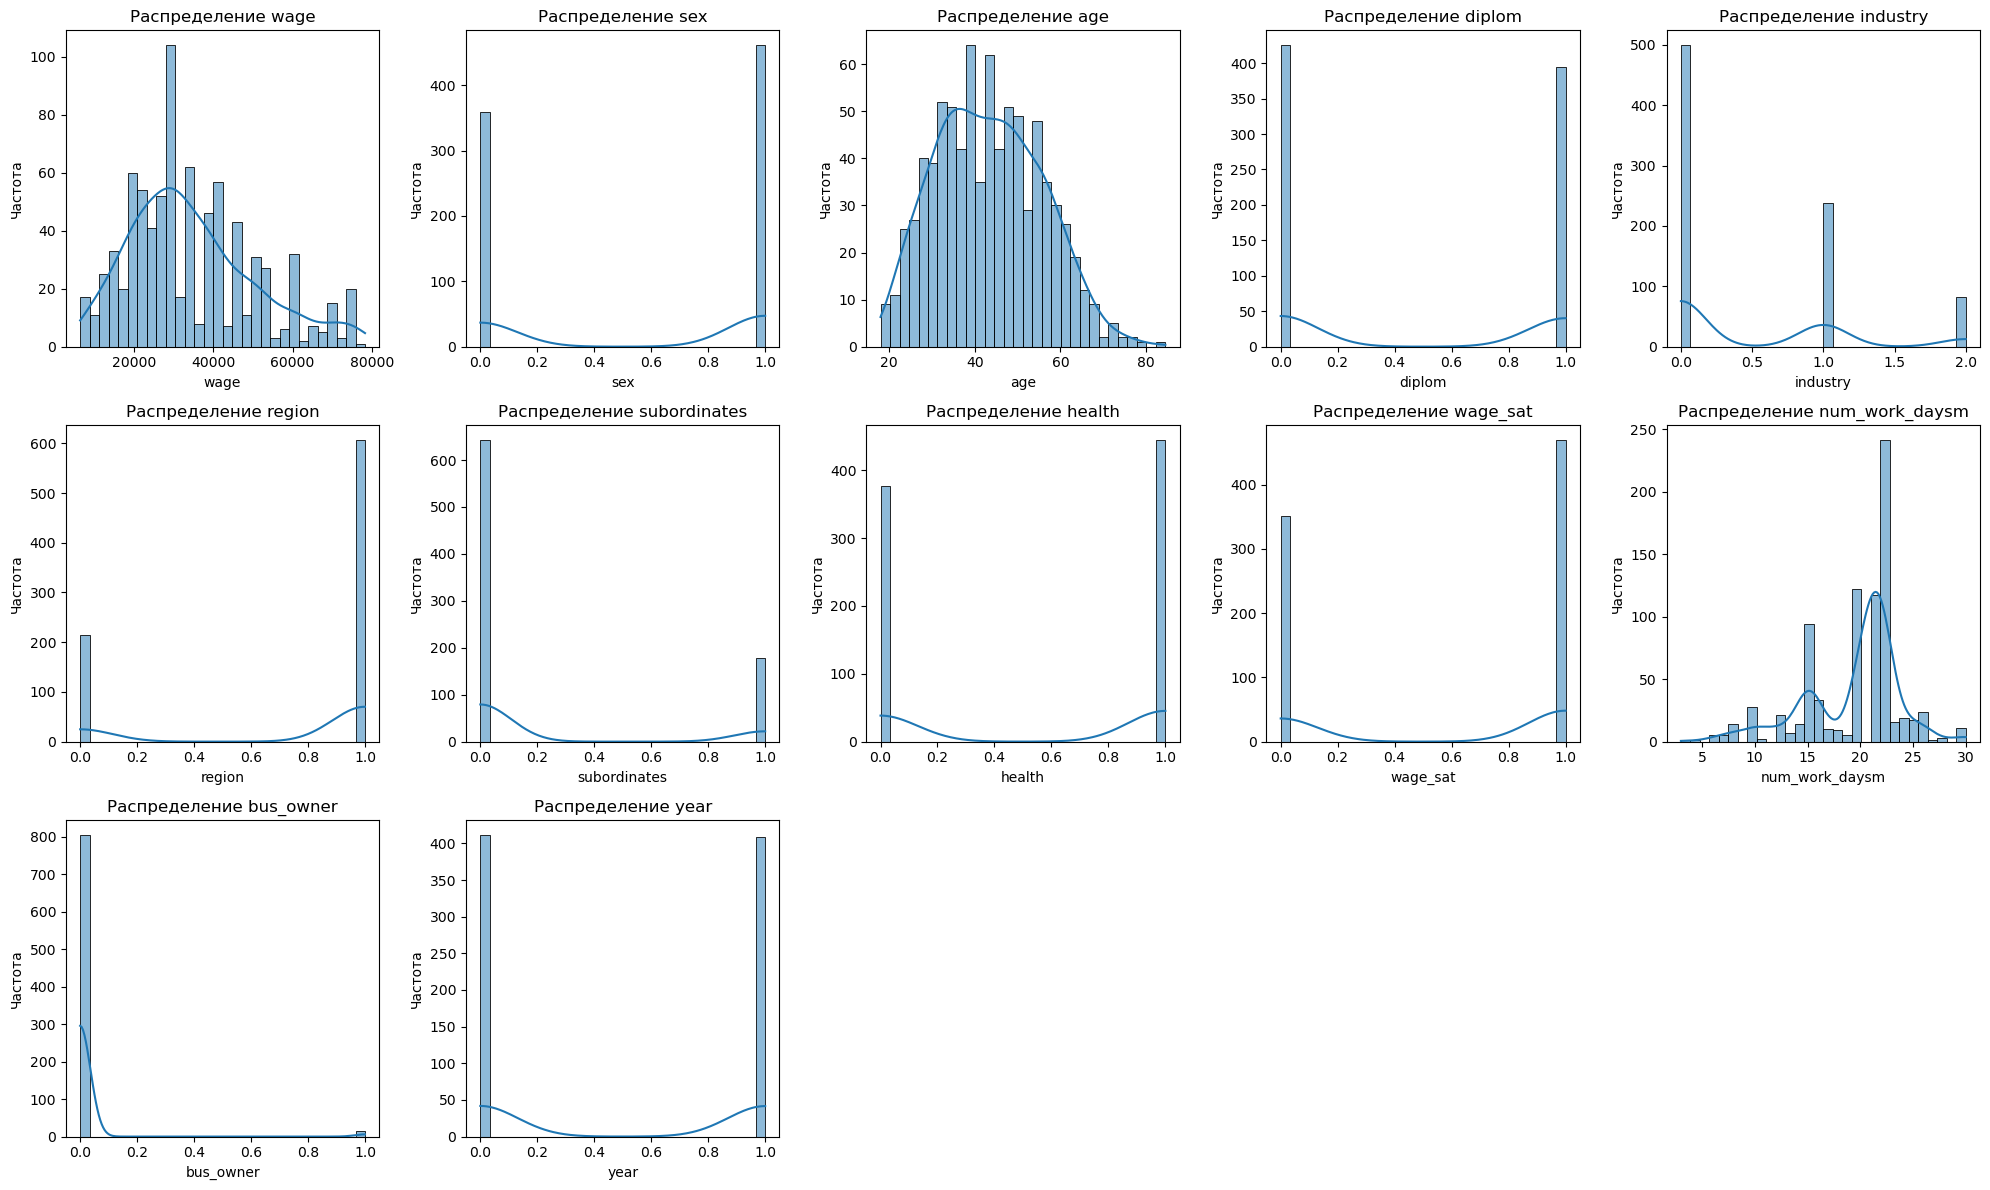

In [41]:
columns_to_plot = list(df_all.columns)
plots_per_row = 5 

num_rows = (len(columns_to_plot) + plots_per_row - 1) // plots_per_row

fig, axes = plt.subplots(num_rows, plots_per_row, figsize=(20, 4 * num_rows))
axes = axes.flatten() 

for i, col in enumerate(columns_to_plot):
    if col in df_all.columns:
        sns.histplot(df_all[col], kde=True, bins=30, ax=axes[i]) 
        axes[i].set_title(f'Распределение {col}')
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Частота')
    else:
        axes[i].set_visible(False)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

#### Ковариационная матрица

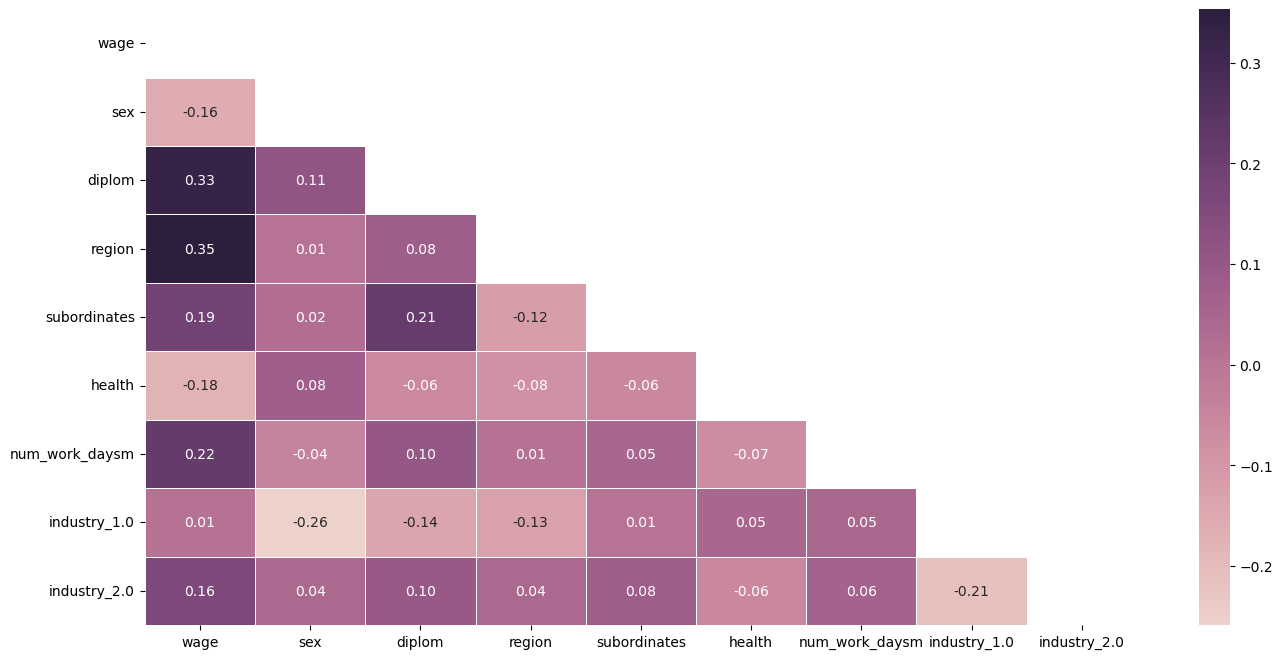

In [269]:
corr_matrix = df_all_dummies.corr()
plt.figure(figsize=(16, 8))
mymap = sns.diverging_palette(240, 240, as_cmap = True)
sns.heatmap(corr_matrix,  fmt=".2f", annot = True, cmap=sns.cubehelix_palette(as_cmap=True), mask=np.triu(corr_matrix), linewidths = 0.5)
plt.show()

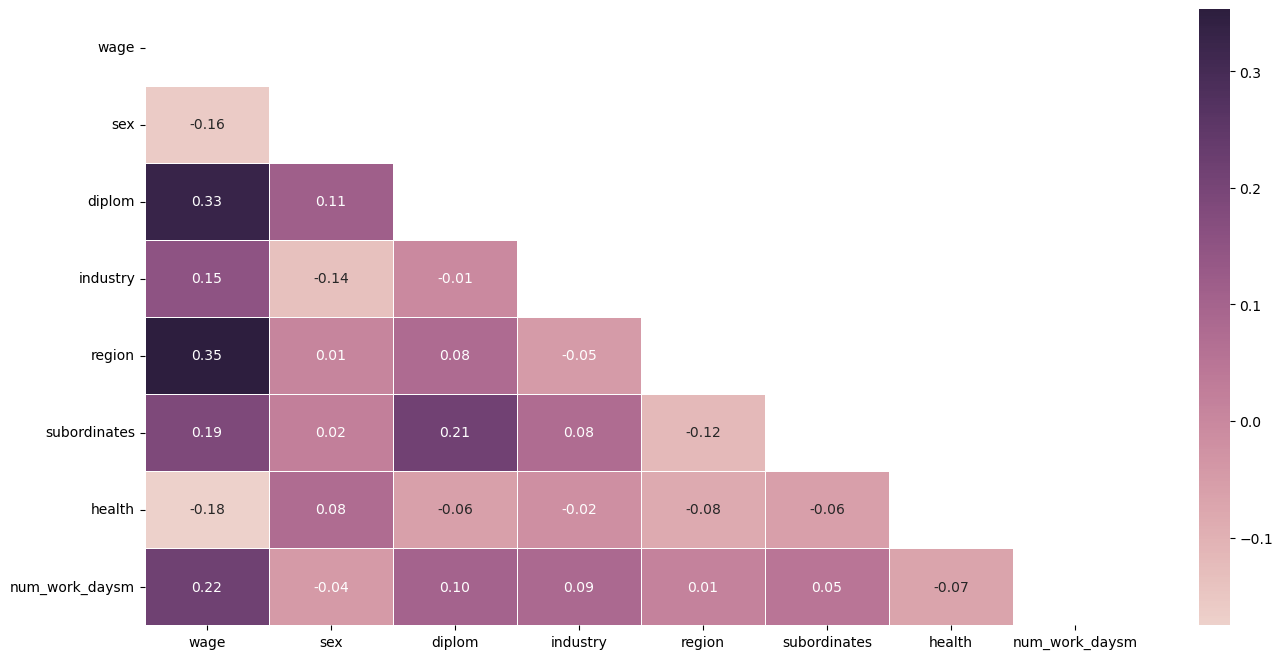

In [413]:
corr_matrix = df_all.drop(['wage_sat', 'bus_owner', 'year', 'age'], axis = 1).corr()
plt.figure(figsize=(16, 8))
mymap = sns.diverging_palette(240, 240, as_cmap = True)
sns.heatmap(corr_matrix,  fmt=".2f", annot = True, cmap=sns.cubehelix_palette(as_cmap=True), mask=np.triu(corr_matrix), linewidths = 0.5)
plt.show()

#### Линейность отдельного регрессора

C:\Users\User\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


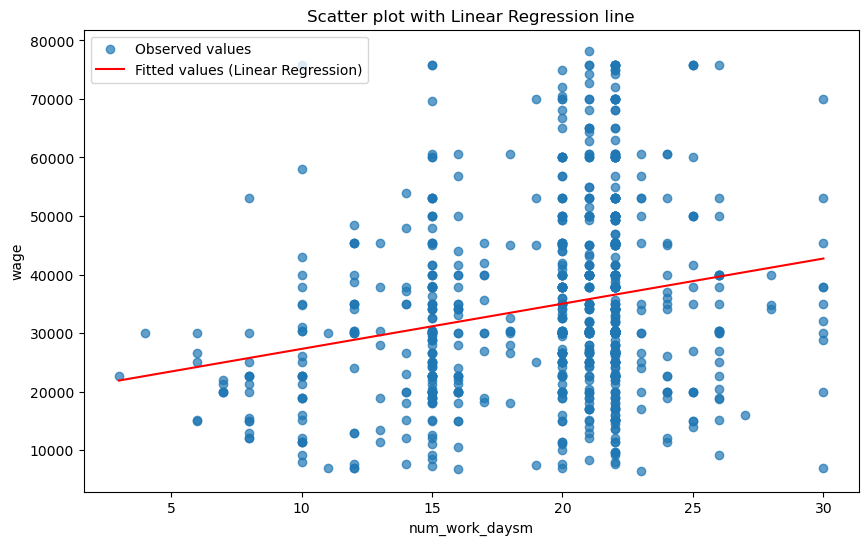

In [265]:
x_column = 'num_work_daysm'  
y_column = 'wage' 

# X = np.log(df_all[[x_column]])
X = df_all[[x_column]]
y = df_all[y_column]   

model = LinearRegression()
model.fit(X, y)

x_fit = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
y_fit = model.predict(x_fit)

# Построение графика
plt.figure(figsize=(10, 6))
plt.scatter(df_all[x_column], df_all[y_column], alpha=0.7, label='Observed values')
plt.plot(x_fit, y_fit, color='red', label='Fitted values (Linear Regression)')
plt.xlabel(x_column)
plt.ylabel(y_column)
plt.title('Scatter plot with Linear Regression line')
plt.legend()
plt.show()

(array([ 25.,  28.,  42.,  71.,  64.,  83., 105.,  78.,  53.,  58.,  48.,
         13.,  57.,   4.,  26.,  14.,   8.,  19.,   5.,  19.]),
 array([ 6500.        , 10087.87878788, 13675.75757576, 17263.63636364,
        20851.51515152, 24439.39393939, 28027.27272727, 31615.15151515,
        35203.03030303, 38790.90909091, 42378.78787879, 45966.66666667,
        49554.54545455, 53142.42424242, 56730.3030303 , 60318.18181818,
        63906.06060606, 67493.93939394, 71081.81818182, 74669.6969697 ,
        78257.57575758]),
 <BarContainer object of 20 artists>)

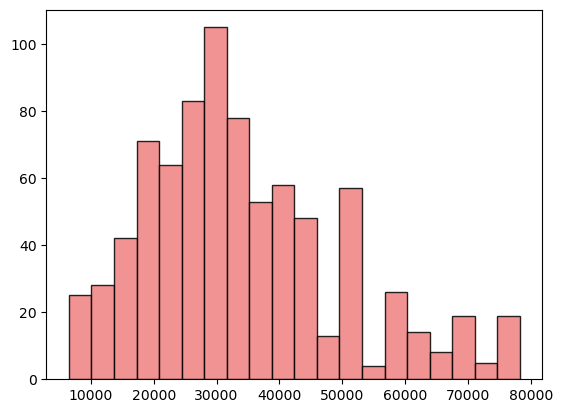

In [510]:
plt.hist(y, bins=20, color='lightcoral', edgecolor='black', alpha = 0.85)

In [87]:
# print(df_all.shape)
# df_all = df_all[df_all['work_week'] < 84]
# print(df_all.shape)

## Model

In [478]:
wage = df_all_dummies['wage']
wage = np.log(wage)
# lambda_optimal = 0.5
# wage = (wage ** lambda_optimal - 1) / lambda_optimal

In [456]:
df_all_dummies['age_squared'] = df_all_dummies['age'] ** 2
print(df_all_dummies.shape)
df_all_dummies.describe()

(820, 14)


,wage,sex,age,diplom,region,subordinates,health,wage_sat,num_work_daysm,bus_owner,year,industry_1.0,industry_2.0,age_squared
count,820.000000,820.000000,820.000000,820.000000,820.000000,820.000000,820.000000,820.000000,820.000000,820.000000,820.000000,820.000000,820.000000,820.000000
mean,34540.958389,0.562195,43.297561,0.481707,0.739024,0.217073,0.541463,0.571951,19.393902,0.019512,0.498780,0.290244,0.101220,2026.218902
std,15830.858539,0.496419,12.317676,0.499970,0.439435,0.412504,0.498582,0.495098,4.475652,0.138401,0.500304,0.454152,0.301803,1117.568267
min,6500.000000,0.000000,18.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000,0.000000,0.000000,0.000000,0.000000,324.000000
25%,22727.272727,0.000000,34.000000,0.000000,0.000000,0.000000,0.000000,0.000000,16.000000,0.000000,0.000000,0.000000,0.000000,1156.000000
50%,30303.030303,1.000000,43.000000,0.000000,1.000000,0.000000,1.000000,1.000000,21.000000,0.000000,0.000000,0.000000,0.000000,1849.000000
75%,45000.000000,1.000000,52.500000,1.000000,1.000000,0.000000,1.000000,1.000000,22.000000,0.000000,1.000000,1.000000,0.000000,2756.250000
max,78257.575758,1.000000,84.500000,1.000000,1.000000,1.000000,1.000000,1.000000,30.000000,1.000000,1.000000,1.000000,1.000000,7140.250000


In [458]:
df_all_dummies = df_all_dummies.drop(columns = ['year']) #, 'age', 'work_week', 
df_all_dummies = df_all_dummies.drop(columns = ['bus_owner']) #, 'age'
df_all_dummies = df_all_dummies.drop(columns = ['age', 'age_squared'])
df_all_dummies = df_all_dummies.drop(columns = ['wage_sat'])

In [91]:
# df_all_dummies = df_all_dummies.drop(columns = ['children']) #, 'age'

In [93]:
# df_all_dummies = df_all_dummies.drop(columns = ['marital_stat']) #, 'age'

In [124]:
# df_all_dummies = df_all_dummies.drop(columns = ['sex_wage_sat'])

In [96]:
# df_all_dummies = df_all_dummies.drop(columns = ['region_industry_1'])

In [97]:
# df_all_dummies = df_all_dummies.drop(columns = ['region_industry_2'])

In [98]:
# df_all_dummies.age = np.log(df_all_dummies.age)
# df_all_dummies.age_squared = np.log(df_all_dummies.age_squared)
# df_all_dummies.num_work_daysm = np.log(df_all_dummies.num_work_daysm)
# df_all_dummies.work_week = np.log(df_all_dummies.work_week)

In [267]:
df_all_dummies.describe()

,wage,sex,diplom,region,subordinates,health,num_work_daysm,industry_1.0,industry_2.0
count,820.000000,820.000000,820.000000,820.000000,820.000000,820.000000,820.000000,820.000000,820.000000
mean,34540.958389,0.562195,0.481707,0.739024,0.217073,0.541463,19.393902,0.290244,0.101220
std,15830.858539,0.496419,0.499970,0.439435,0.412504,0.498582,4.475652,0.454152,0.301803
min,6500.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000,0.000000,0.000000
25%,22727.272727,0.000000,0.000000,0.000000,0.000000,0.000000,16.000000,0.000000,0.000000
50%,30303.030303,1.000000,0.000000,1.000000,0.000000,1.000000,21.000000,0.000000,0.000000
75%,45000.000000,1.000000,1.000000,1.000000,0.000000,1.000000,22.000000,1.000000,0.000000
max,78257.575758,1.000000,1.000000,1.000000,1.000000,1.000000,30.000000,1.000000,1.000000


In [480]:
factors_all = sm.add_constant(df_all_dummies.drop(columns = ['wage'])).astype(float)
model1 = sm.OLS(wage, factors_all).fit(cov_type='HC3')
# model1 = sm.OLS(wage, factors_all).fit()
print(model1.summary())

                            OLS Regression Results                            
Dep. Variable:                   wage   R-squared:                       0.368
Model:                            OLS   Adj. R-squared:                  0.362
Method:                 Least Squares   F-statistic:                     52.43
Date:                Thu, 19 Dec 2024   Prob (F-statistic):           1.76e-68
Time:                        03:41:39   Log-Likelihood:                -400.38
No. Observations:                 820   AIC:                             818.8
Df Residuals:                     811   BIC:                             861.1
Df Model:                           8                                         
Covariance Type:                  HC3                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
const              9.5984      0.081    118.

In [406]:
y_actual = wage
y_predicted = model1.predict()

In [243]:
print(wage.shape, y_predicted.shape)

(820,) (820,)


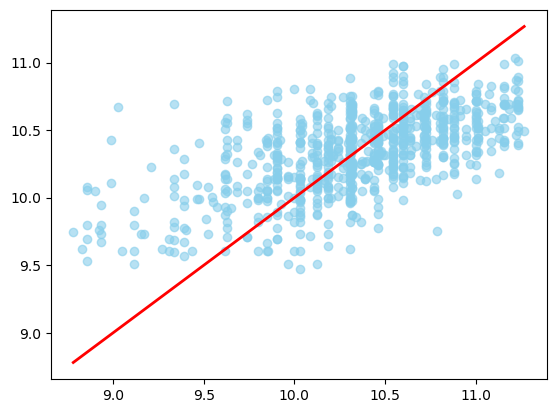

In [408]:
plt.scatter(y_actual, y_predicted, alpha=0.6,  color='skyblue')
plt.plot(
    [y_actual.min(), y_actual.max()],
    [y_actual.min(), y_actual.max()],
    color="red",
    linewidth=2,
)
plt.show()

### Мультиколлинераность VIF тест

In [482]:
factors_no_const = factors_all.drop(columns=['const'], errors='ignore')
vif_test = pd.Series([vif(factors_no_const.values, i) for i in range(factors_no_const.shape[1])], index=factors_no_const.columns)
#vif_test2 = pd.Series([vif(factors_all.values, i) for i in range(factors_all.shape[1])], index=factors_all.columns)

if any(vif_test > 10):
    print("Есть признаки мультиколлинеарности (VIF > 10).")
else:
    print("Мультиколлинеарность отсутствует.")

print(vif_test)#, vif_test2)

Мультиколлинеарность отсутствует.
sex               2.326313
diplom            2.117223
region            3.512968
subordinates      1.366065
health            2.078700
num_work_daysm    6.644993
industry_1.0      1.573207
industry_2.0      1.183620
dtype: float64


### Норм таргет (Колмогорова-Смирнова)

In [484]:
target_variable = df_all_dummies['wage'] 

target_z = zscore(target_variable)

ks_statistic, p_value = kstest(target_z, 'norm')

print(f"KS статистика: {ks_statistic}")
print(f"P-value: {p_value}")

alpha = 0.05
if p_value < alpha:
    print("Распределение целевой переменной статистически отличается от нормального (отвергаем H0).")
else:
    print("Нет оснований отвергать гипотезу нормальности распределения (принимаем H0).")

KS статистика: 0.11413452107486449
P-value: 9.229360790964924e-10
Распределение целевой переменной статистически отличается от нормального (отвергаем H0).


### 3 на гетероскастичности и 2 на нормальность остатков

In [486]:
X = factors_all
y = df_all_dummies['wage'] 
residuals = model1.resid

#### Уайта

In [488]:
white_test = het_white(residuals, X)
lm_statistic, lm_pvalue, f_statistic, f_pvalue = white_test

print(f"LM Statistic: {lm_statistic}")
print(f"LM p-value: {lm_pvalue}")
print(f"F Statistic: {f_statistic}")
print(f"F p-value: {f_pvalue}")

if lm_pvalue < 0.05 or f_pvalue < 0.05:
    print("Есть признаки гетероскедастичности")
else:
    print("Нет признаков гетероскедастичности")

LM Statistic: 51.74349014513462
LM p-value: 0.04324033925461367
F Statistic: 1.4649025373950761
F p-value: 0.04002501387433495
Есть признаки гетероскедастичности


#### Бройша-Пагана

In [490]:
bp_test = het_breuschpagan(residuals, X)
lm_statistic, lm_pvalue, f_statistic, f_pvalue = bp_test

print(f"LM Statistic: {lm_statistic}")
print(f"LM p-value: {lm_pvalue}")
print(f"F Statistic: {f_statistic}")
print(f"F p-value: {f_pvalue}")

if lm_pvalue < 0.05 or f_pvalue < 0.05:
    print("Есть признаки гетероскедастичности")
else:
    print("Нет признаков гетероскедастичности")

LM Statistic: 6.29028131775944
LM p-value: 0.6147514365814011
F Statistic: 0.7836667720038378
F p-value: 0.6172072043483063
Нет признаков гетероскедастичности


#### Нормальность остатков Шапиро-Уилка

In [492]:
shapiro_test = shapiro(residuals)
print(f"\nShapiro-Wilk p-value: {shapiro_test.pvalue:.5f}")

if shapiro_test.pvalue < 0.05:
    print("Остатки не являются нормальными (отвергаем H0).")
else:
    print("Остатки близки к нормальному распределению.")


Shapiro-Wilk p-value: 0.00000
Остатки не являются нормальными (отвергаем H0).


#### Харке-Бера

In [474]:
statistic, p_value = jarque_bera(residuals)

print(f"Jarque-Bera statistic: {statistic}")
print(f"p-value: {p_value}")

alpha = 0.05 
if p_value > alpha:
    print("Остатки близки к нормальному распределению.")
else:
    print("Остатки не являются нормальными (отвергаем H0).")

Jarque-Bera statistic: 37.506602074328555
p-value: 7.170424083414361e-09
Остатки не являются нормальными (отвергаем H0).


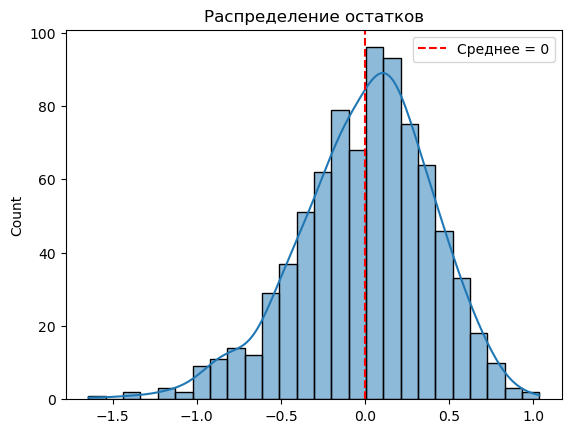

In [494]:
sns.histplot(residuals, kde=True)
plt.axvline(x=0, color='red', linestyle='--', label='Среднее = 0')
plt.title("Распределение остатков")
plt.legend()
plt.show()

In [113]:
round(residuals.mean(), 14)

-2e-14

### Тест Рамсея

In [384]:
reset_test = linear_reset(model1, power=2, use_f=True)

f_statistic, p_value = reset_test.fvalue, reset_test.pvalue

print(f"F-Statistic: {f_statistic:.4f}")
print(f"P-value: {p_value:.4f}")

if p_value < 0.05:
    print("Есть признаки неправильной спецификации модели (отвергаем H0).")
else:
    print("Нет оснований отвергать H0 — спецификация модели корректна.")

F-Statistic: 8.3426
P-value: 0.0040
Есть признаки неправильной спецификации модели (отвергаем H0).


C:\Users\User\anaconda3\Lib\site-packages\statsmodels\stats\diagnostic.py:1065: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  aug = res.fittedvalues[:, None]


In [386]:
y = model1.model.endog
X = model1.model.exog

RSS_2 = np.sum(model1.resid**2)
k1 = X.shape[1]
n = X.shape[0]

X_expanded = np.column_stack([X, X[:, 1] ** 2])
X_expanded = sm.add_constant(X_expanded)

model_expanded = sm.OLS(y, X_expanded).fit()
RSS_1 = np.sum(model_expanded.resid**2)
k2 = X_expanded.shape[1]

F_stat = ((RSS_2 - RSS_1) / (k2 - k1)) / (RSS_1 / (n - k2))

df1 = k2 - k1
df2 = n - k2

p_value = 1 - f.cdf(F_stat, df1, df2)

print("F-статистика:", F_stat)
print("P-value:", p_value)

if p_value < 0.05:
    print("Спецификация модели неверна (отвергаем H0)")
else:
    print("Нет оснований отвергать корректность спецификации модели (принимаем H0)")

F-статистика: 2.708855298891315e-13
P-value: 0.9999995848558492
Нет оснований отвергать корректность спецификации модели (принимаем H0)


### Тест Чоу 

#### По полу

In [388]:
y = df_all_dummies['wage']
X = sm.add_constant(df_all_dummies.drop(columns = ['wage'])).astype(float)

df_man = df_all_dummies[df_all_dummies['sex'] == 0]
y1 = df_man['wage']
X1 = sm.add_constant(df_man.drop(columns = ['wage'])).astype(float)

df_wom = df_all_dummies[df_all_dummies['sex'] == 1]
y2 = df_wom['wage']
X2 = sm.add_constant(df_wom.drop(columns = ['wage'])).astype(float)

In [390]:
model_full = sm.OLS(y, X).fit()     
model1 = sm.OLS(y1, X1).fit()       
model2 = sm.OLS(y2, X2).fit()     

RSS_full = sum(model_full.resid ** 2)     
RSS1 = sum(model1.resid ** 2)             
RSS2 = sum(model2.resid ** 2)             

n_full, k = X.shape               
n1 = X1.shape[0]                  
n2 = X2.shape[0]                  

numerator = (RSS_full - (RSS1 + RSS2)) / k
denominator = (RSS1 + RSS2) / (n1 + n2 - 2 * k)
F_statistic = numerator / denominator

p_value = 1 - f.cdf(F_statistic, k, n1 + n2 - 2 * k)

print(f"F-Statistic: {F_statistic:.4f}")
print(f"P-value: {p_value:.4f}")

if p_value < 0.05:
    print("Есть структурный сдвиг между группами (отвергаем H0).")
else:
    print("Нет оснований отвергать H0 — различий между группами не обнаружено.")

F-Statistic: 0.6004
P-value: 0.7973
Нет оснований отвергать H0 — различий между группами не обнаружено.


#### По региону

In [195]:
y = df_all_dummies['wage']
X = sm.add_constant(df_all_dummies.drop(columns = ['wage'])).astype(float)

df_man = df_all_dummies[df_all_dummies['region'] == 0]
y1 = df_man['wage']
X1 = sm.add_constant(df_man.drop(columns = ['wage'])).astype(float)

df_wom = df_all_dummies[df_all_dummies['region'] == 1]
y2 = df_wom['wage']
X2 = sm.add_constant(df_wom.drop(columns = ['wage'])).astype(float)

In [197]:
model_full = sm.OLS(y, X).fit()     
model1 = sm.OLS(y1, X1).fit()       
model2 = sm.OLS(y2, X2).fit()     

RSS_full = sum(model_full.resid ** 2)     
RSS1 = sum(model1.resid ** 2)             
RSS2 = sum(model2.resid ** 2)             

n_full, k = X.shape               
n1 = X1.shape[0]                  
n2 = X2.shape[0]                  

numerator = (RSS_full - (RSS1 + RSS2)) / k
denominator = (RSS1 + RSS2) / (n1 + n2 - 2 * k)
F_statistic = numerator / denominator

p_value = 1 - f.cdf(F_statistic, k, n1 + n2 - 2 * k)

print(f"F-Statistic: {F_statistic:.4f}")
print(f"P-value: {p_value:.4f}")

if p_value < 0.05:
    print("Есть структурный сдвиг между группами (отвергаем H0).")
else:
    print("Нет оснований отвергать H0 — различий между группами не обнаружено.")

F-Statistic: 1.1903
P-value: 0.2977
Нет оснований отвергать H0 — различий между группами не обнаружено.


#### По году

In [121]:
# y = df_all_dummies['wage']
# X = sm.add_constant(df_all_dummies.drop(columns = ['wage'])).astype(float)

# df_man = df_all_dummies[df_all_dummies['year'] == 0]
# y1 = df_man['wage']
# X1 = sm.add_constant(df_man.drop(columns = ['wage'])).astype(float)

# df_wom = df_all_dummies[df_all_dummies['year'] == 1]
# y2 = df_wom['wage']
# X2 = sm.add_constant(df_wom.drop(columns = ['wage'])).astype(float)

In [122]:
# model_full = sm.OLS(y, X).fit()     
# model1 = sm.OLS(y1, X1).fit()       
# model2 = sm.OLS(y2, X2).fit()     

# RSS_full = sum(model_full.resid ** 2)     
# RSS1 = sum(model1.resid ** 2)             
# RSS2 = sum(model2.resid ** 2)             

# n_full, k = X.shape               
# n1 = X1.shape[0]                  
# n2 = X2.shape[0]                  

# numerator = (RSS_full - (RSS1 + RSS2)) / k
# denominator = (RSS1 + RSS2) / (n1 + n2 - 2 * k)
# F_statistic = numerator / denominator

# p_value = 1 - f.cdf(F_statistic, k, n1 + n2 - 2 * k)

# print(f"F-Statistic: {F_statistic:.4f}")
# print(f"P-value: {p_value:.4f}")

# if p_value < 0.05:
#     print("Есть структурный сдвиг между группами (отвергаем H0).")
# else:
#     print("Нет оснований отвергать H0 — различий между группами не обнаружено.")

### Тест Бокса Кокса

Оптимальное значение лямбда: 0.3820


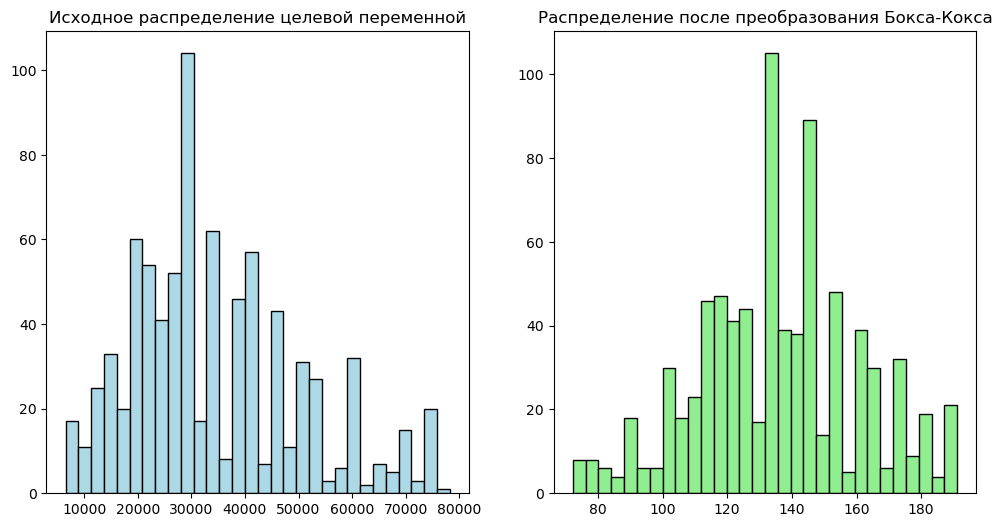

In [199]:
y = df_all_dummies['wage']

if (y <= 0).any():
    raise ValueError("Тест Бокса-Кокса требует, чтобы все значения целевой переменной были положительными.")

y_transformed, lambda_optimal = stats.boxcox(y)

print(f"Оптимальное значение лямбда: {lambda_optimal:.4f}")

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)

plt.hist(y, bins=30, color='lightblue', edgecolor='black')
plt.title("Исходное распределение целевой переменной")

plt.subplot(1, 2, 2)
plt.hist(y_transformed, bins=30, color='lightgreen', edgecolor='black')
plt.title("Распределение после преобразования Бокса-Кокса")

plt.show()